<a href="https://colab.research.google.com/github/SafiBD/machine-learning/blob/main/ML_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Android Ransomware Detection Detection**

## **Font family setup**

In [47]:
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [48]:
#Dataset Link: https://www.kaggle.com/datasets/subhajournal/android-ransomware-detection

## **Importing Dataset**

In [49]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [50]:
# Access the file in Google Drive
df = pd.read_excel("/content/drive/MyDrive/Python for ML/WE_main.xlsx")

## **Basic Information**

In [51]:
df

,Respondent's current age,Age in 5-year groups,Division,Type of place of residence,Division.1,Type of place of residence.1,Religion,Education in single years,Educational attainment,Owns a mobile telephone,...,Person who usually decides on: large household purchases,Person who usually decides on: visits to family or relatives,Person who usually decides on: what to do with money husband earns,Beating justified if wife goes out without telling husband,Beating justified if wife neglects the children,Beating justified if wife argues with husband,Beating justified if wife refuses to have sex with husband,Beating justified if wife burns the food,Owns a house alone or jointly,Owns land alone or jointly
0,46,45-49,Barishal,Urban,Barishal,Urban,Islam,15,Higher,Yes,...,Respondent and husband/partner,Respondent and husband/partner,Respondent and husband/partner,No,No,No,No,No,Does not own,Does not own
1,49,45-49,Barishal,Urban,Barishal,Urban,Islam,8,Incomplete secondary,Yes,...,Respondent and husband/partner,Respondent alone,Husband/partner has no earnings,No,No,No,No,No,Does not own,Does not own
2,27,25-29,Barishal,Urban,Barishal,Urban,Islam,10,Complete secondary,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,40,40-44,Barishal,Urban,Barishal,Urban,Islam,5,Complete primary,No,...,Respondent and husband/partner,Respondent and husband/partner,Respondent and husband/partner,No,No,No,No,No,Does not own,Does not own
4,49,45-49,Barishal,Urban,Barishal,Urban,Islam,5,Complete primary,Yes,...,Husband/partner alone,Respondent and husband/partner,Respondent and husband/partner,No,No,No,No,No,Alone only,Alone only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30073,39,35-39,Sylhet,Rural,Sylhet,Rural,Islam,5,Complete primary,No,...,Husband/partner alone,Respondent and husband/partner,Respondent and husband/partner,No,No,No,No,No,Does not own,Does not own
30074,20,20-24,Sylhet,Rural,Sylhet,Rural,Islam,9,Incomplete secondary,No,...,NaN,NaN,NaN,No,No,No,No,No,Does not own,Does not own
30075,29,25-29,Sylhet,Rural,Sylhet,Rural,Islam,5,Complete primary,No,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30076,34,30-34,Sylhet,Rural,Sylhet,Rural,Islam,6,Incomplete secondary,No,...,Respondent and husband/partner,Respondent and husband/partner,Respondent and husband/partner,No,No,No,No,No,Does not own,Does not own


In [52]:
df.shape

(30078, 30)

In [53]:
df.columns

Index(['Respondent's current age', 'Age in 5-year groups', 'Division',
       'Type of place of residence', 'Division.1',
       'Type of place of residence.1', 'Religion', 'Education in single years',
       'Educational attainment', 'Owns a mobile telephone',
       'Has an account in a bank or other financial institution',
       'Use of internet', 'Wealth index combined',
       'Ever used anything or tried to delay or avoid getting pregnant',
       'Current contraceptive method',
       'Decision maker for using contraception',
       'Husband/partner's education level', 'Respondent currently working',
       'Husband/partner's age',
       'Person who usually decides on: respondent's health care',
       'Person who usually decides on: large household purchases',
       'Person who usually decides on: visits to family or relatives',
       'Person who usually decides on: what to do with money husband earns',
       'Beating justified if wife goes out without telling husband',
  

In [54]:
df['Ever used anything or tried to delay or avoid getting pregnant'].value_counts()

,count
Ever used anything or tried to delay or avoid getting pregnant,
"Yes, used in calendar",15354
No,3547
"Yes, used outside calendar",1086


## **Data Samples per Class**

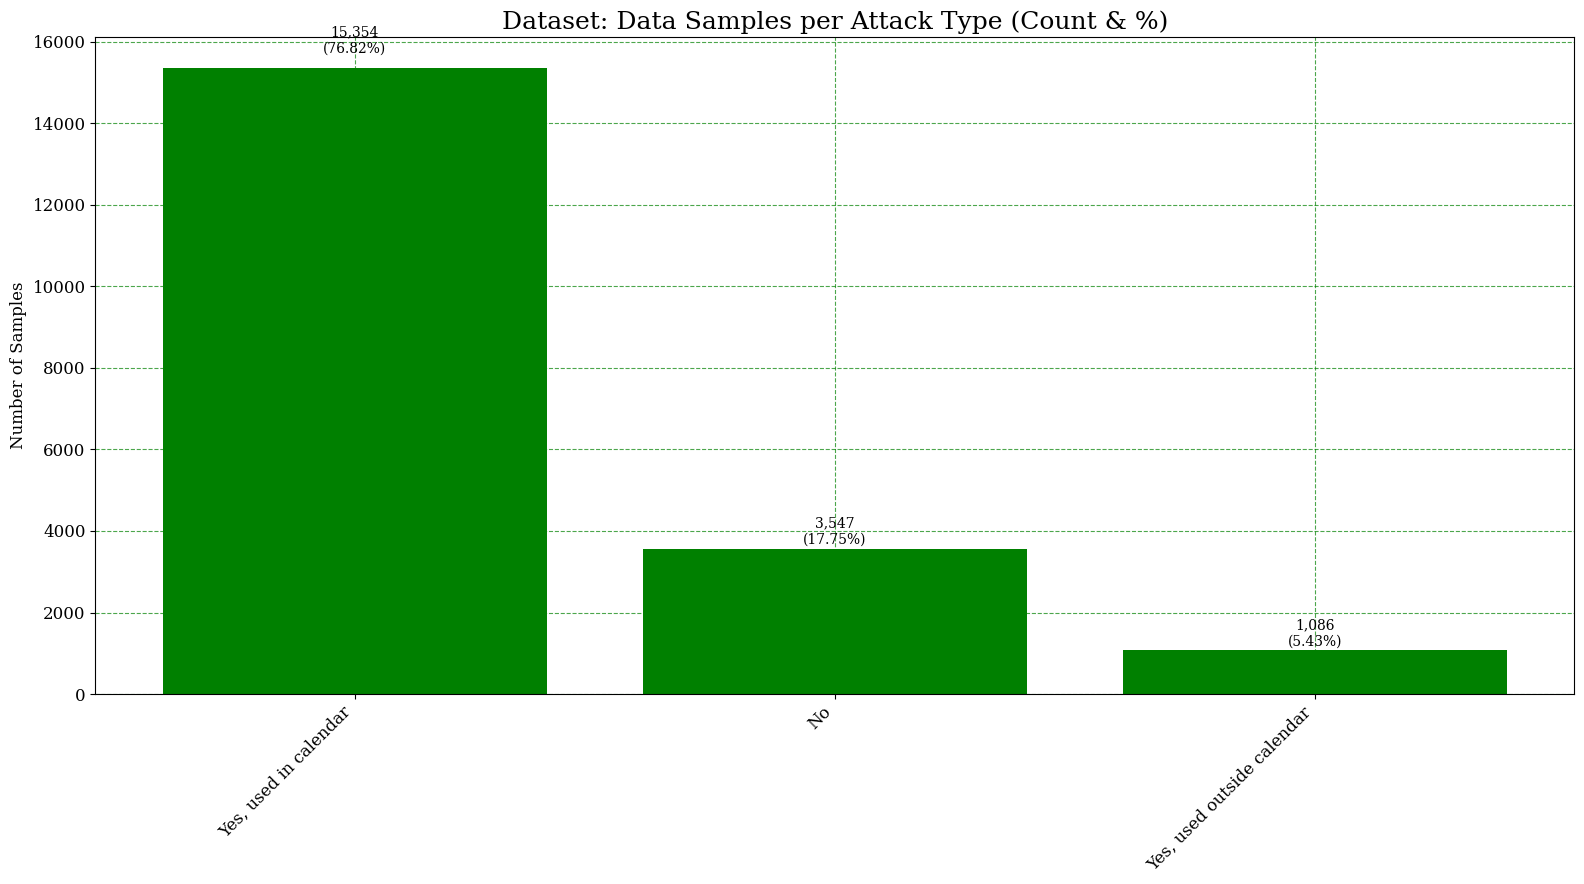

In [55]:
import matplotlib.pyplot as plt

# Count samples and percentages
label_counts = df['Ever used anything or tried to delay or avoid getting pregnant'].value_counts()
label_percentages = (label_counts / label_counts.sum()) * 100

# Set up the plot
plt.figure(figsize=(16, 9))
bars = plt.bar(label_counts.index, label_counts.values, color='green')  # Bar color set to green

# Add count and percentage text above each bar
for idx, bar in enumerate(bars):
    height = bar.get_height()
    count_text = f'{label_counts.values[idx]:,}'
    percent_text = f'({label_percentages.values[idx]:.2f}%)'

    plt.text(
        bar.get_x() + bar.get_width()/2, height + 0.02*height,
        f'{count_text}\n{percent_text}',
        ha='center', va='bottom', fontsize=10
    )

# Titles and labels
plt.title('Dataset: Data Samples per Attack Type (Count & %)', fontsize=18)
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
#plt.grid(axis='y', linestyle='--', alpha=0.7, color='green')  # Grid color set to green
# Enable both horizontal and vertical green grid lines
plt.grid(axis='both', linestyle='--', alpha=0.7, color='green')

plt.tight_layout()

# Show plot
plt.show()


## **Handle Missing Values**

In [56]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill missing values in categorical columns with mode
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled



Columns with Missing Values:
 Has an account in a bank or other financial institution               10091
Use of internet                                                       10091
Ever used anything or tried to delay or avoid getting pregnant        10091
Current contraceptive method                                          10091
Decision maker for using contraception                                11091
Husband/partner's education level                                     11091
Respondent currently working                                          10091
Husband/partner's age                                                 11091
Person who usually decides on: respondent's health care               11091
Person who usually decides on: large household purchases              11091
Person who usually decides on: visits to family or relatives          11091
Person who usually decides on: what to do with money husband earns    11091
Beating justified if wife goes out without telling husband

In [57]:
# Print the names of the features (columns)
print(df.columns)

Index(['Respondent's current age', 'Age in 5-year groups', 'Division',
       'Type of place of residence', 'Division.1',
       'Type of place of residence.1', 'Religion', 'Education in single years',
       'Educational attainment', 'Owns a mobile telephone',
       'Has an account in a bank or other financial institution',
       'Use of internet', 'Wealth index combined',
       'Ever used anything or tried to delay or avoid getting pregnant',
       'Current contraceptive method',
       'Decision maker for using contraception',
       'Husband/partner's education level', 'Respondent currently working',
       'Husband/partner's age',
       'Person who usually decides on: respondent's health care',
       'Person who usually decides on: large household purchases',
       'Person who usually decides on: visits to family or relatives',
       'Person who usually decides on: what to do with money husband earns',
       'Beating justified if wife goes out without telling husband',
  

## **Data Preprocessing**

In [58]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Preprocessing steps
# Replace infinity and large values with NaNs
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)

# Drop rows containing NaNs
df.dropna(inplace=True)

# Separate numerical and categorical columns, excluding the 'Label' column from categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Label'])

# Normalize numerical columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Ensure all categorical values are strings
df[cat_cols] = df[cat_cols].astype(str)

# Encode categorical columns
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)

# Display the processed DataFrame
df

,Respondent's current age,Age in 5-year groups,Division,Type of place of residence,Division.1,Type of place of residence.1,Religion,Education in single years,Educational attainment,Owns a mobile telephone,...,Person who usually decides on: large household purchases,Person who usually decides on: visits to family or relatives,Person who usually decides on: what to do with money husband earns,Beating justified if wife goes out without telling husband,Beating justified if wife neglects the children,Beating justified if wife argues with husband,Beating justified if wife refuses to have sex with husband,Beating justified if wife burns the food,Owns a house alone or jointly,Owns land alone or jointly
0,1.571560,6,0,1,0,1,3,1.917711,2,1,...,3,3,4,1,1,1,1,1,2,2
1,1.908586,6,0,1,0,1,3,0.278749,4,1,...,3,2,1,1,1,1,1,1,2,2
2,-0.562934,2,0,1,0,1,3,0.747024,1,1,...,3,3,4,1,1,1,1,1,2,2
3,0.897509,5,0,1,0,1,3,-0.423663,0,0,...,3,3,4,1,1,1,1,1,2,2
4,1.908586,6,0,1,0,1,3,-0.423663,0,1,...,0,3,4,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30073,0.785168,4,7,0,7,0,3,-0.423663,0,0,...,0,3,4,1,1,1,1,1,2,2
30074,-1.349327,1,7,0,7,0,3,0.512887,4,0,...,3,3,4,1,1,1,1,1,2,2
30075,-0.338251,2,7,0,7,0,3,-0.423663,0,0,...,3,3,4,1,1,1,1,1,2,2
30076,0.223459,3,7,0,7,0,3,-0.189525,4,0,...,3,3,4,1,1,1,1,1,2,2


In [59]:
#df.drop(columns=['Unnamed: 0'], inplace=True)

In [60]:
df

,Respondent's current age,Age in 5-year groups,Division,Type of place of residence,Division.1,Type of place of residence.1,Religion,Education in single years,Educational attainment,Owns a mobile telephone,...,Person who usually decides on: large household purchases,Person who usually decides on: visits to family or relatives,Person who usually decides on: what to do with money husband earns,Beating justified if wife goes out without telling husband,Beating justified if wife neglects the children,Beating justified if wife argues with husband,Beating justified if wife refuses to have sex with husband,Beating justified if wife burns the food,Owns a house alone or jointly,Owns land alone or jointly
0,1.571560,6,0,1,0,1,3,1.917711,2,1,...,3,3,4,1,1,1,1,1,2,2
1,1.908586,6,0,1,0,1,3,0.278749,4,1,...,3,2,1,1,1,1,1,1,2,2
2,-0.562934,2,0,1,0,1,3,0.747024,1,1,...,3,3,4,1,1,1,1,1,2,2
3,0.897509,5,0,1,0,1,3,-0.423663,0,0,...,3,3,4,1,1,1,1,1,2,2
4,1.908586,6,0,1,0,1,3,-0.423663,0,1,...,0,3,4,1,1,1,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30073,0.785168,4,7,0,7,0,3,-0.423663,0,0,...,0,3,4,1,1,1,1,1,2,2
30074,-1.349327,1,7,0,7,0,3,0.512887,4,0,...,3,3,4,1,1,1,1,1,2,2
30075,-0.338251,2,7,0,7,0,3,-0.423663,0,0,...,3,3,4,1,1,1,1,1,2,2
30076,0.223459,3,7,0,7,0,3,-0.189525,4,0,...,3,3,4,1,1,1,1,1,2,2


## **After Processing**

In [61]:
df['Ever used anything or tried to delay or avoid getting pregnant'].value_counts()

,count
Ever used anything or tried to delay or avoid getting pregnant,
1,25445
0,3547
2,1086


In [62]:
####Copy the processed df to different df

df1 = df.copy()
df2 = df.copy()
df3 = df.copy()

# **Binary Class (Anomaly) Classification**

In [71]:

df1['Ever used anything or tried to delay or avoid getting pregnant'] = df1['Ever used anything or tried to delay or avoid getting pregnant'].apply(lambda x: 0 if x == 0 else 1)


In [72]:
# Check counts
print(df1['Ever used anything or tried to delay or avoid getting pregnant'].value_counts())

Ever used anything or tried to delay or avoid getting pregnant
1    26531
0     3547
Name: count, dtype: int64


In [73]:
# Define label and feature columns
X = df1.drop(columns=['Ever used anything or tried to delay or avoid getting pregnant'])
y = df1['Ever used anything or tried to delay or avoid getting pregnant']

## **Traing and Test Division**

In [74]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.3,          # 20% test, 80% train
    random_state=42,        # For reproducibility
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (21054, 29)
X_test shape:  (9024, 29)
y_train shape: (21054,)
y_test shape:  (9024,)


## **Train & Evaluate Decision Tree Classifier**

Accuracy:  0.8720
Precision: 0.8762
Recall:    0.8720
F1 Score:  0.8740


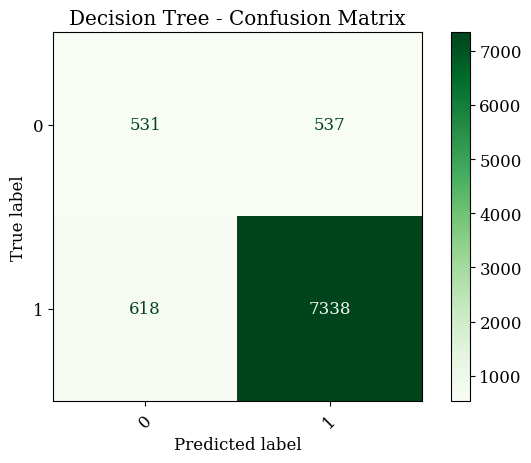

Classification Report:
              precision    recall  f1-score   support

           0    0.46214   0.49719   0.47903      1068
           1    0.93181   0.92232   0.92704      7956

    accuracy                        0.87201      9024
   macro avg    0.69698   0.70976   0.70303      9024
weighted avg    0.87622   0.87201   0.87402      9024



In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

Accuracy:  0.87378
Precision: 0.85382
Recall:    0.87378
F1 Score:  0.86115


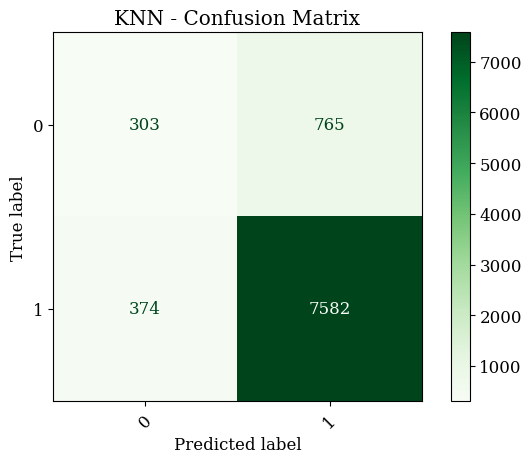

Classification Report:
              precision    recall  f1-score   support

           0    0.44756   0.28371   0.34728      1068
           1    0.90835   0.95299   0.93014      7956

    accuracy                        0.87378      9024
   macro avg    0.67796   0.61835   0.63871      9024
weighted avg    0.85382   0.87378   0.86115      9024



In [76]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Logistic Regression Classifier**

Accuracy:  0.8814
Precision: 0.8069
Recall:    0.8814
F1 Score:  0.8263


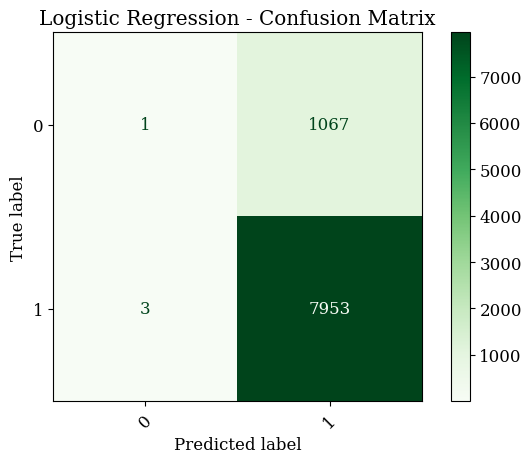

Classification Report:
              precision    recall  f1-score   support

           0    0.25000   0.00094   0.00187      1068
           1    0.88171   0.99962   0.93697      7956

    accuracy                        0.88143      9024
   macro avg    0.56585   0.50028   0.46942      9024
weighted avg    0.80694   0.88143   0.82630      9024



In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

lr_model = LogisticRegression(random_state=42, max_iter=2000, solver='liblinear')
lr_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = lr_model.predict(X_test)

# 3. Evaluation Metrics (same style as your DT code)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lr_model.classes_).plot(cmap='Greens', xticks_rotation=45)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Multiclass Classification**

In [ ]:
# Define label and feature columns
X = df2.drop(columns=['Label'])
y = df2['Label']

## **Traing and Test Division**

In [ ]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,                   # Features and target
    test_size=0.2,          # 20% test, 80% train
    random_state=42,        # For reproducibility
    stratify=y              # Ensures class distribution is preserved
)

# Confirm sizes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")


## **Train & Evaluate Decision Tree Classifier**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = dt_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=dt_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Decision Tree - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate KNN Classifier**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train KNN Classifier
knn_model = KNeighborsClassifier(n_neighbors=5)  # You can tune n_neighbors
knn_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = knn_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics (5-digit precision)
print(f"Accuracy:  {accuracy:.5f}")
print(f"Precision: {precision:.5f}")
print(f"Recall:    {recall:.5f}")
print(f"F1 Score:  {f1:.5f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=knn_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("KNN - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report (5-digit precision)
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

## **Train & Evaluate Logistic Regression Classifier**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# 1. Train Logistic Regression Classifier
lr_model = LogisticRegression(random_state=42, max_iter=2000, solver="liblinear")
lr_model.fit(X_train, y_train)

# 2. Predict on Test Set
y_pred = lr_model.predict(X_test)

# 3. Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# 4. Print Basic Metrics
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=lr_model.classes_).plot(cmap='Greens', xticks_rotation=90)
plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

# 6. Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0, digits=5))

# **Modified Confusion Matrix**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

# Colormap
cmap = sns.color_palette("crest", as_cmap=True)

# Automatically get class labels from model
class_labels = knn_model.classes_

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# Plot CM
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=True,
            ax=ax, annot_kws={"fontsize": 10}, linewidths=1, linecolor='white')

ax.set_title("Confusion Matrix for KNN")
ax.set_xlabel("Predicted Labels")
ax.set_ylabel("True Labels")
ax.set_xticklabels(class_labels, rotation=45)
ax.set_yticklabels(class_labels, rotation=0)

plt.tight_layout()
plt.show()


# **Thank you Everyone!**